In [33]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from constants import con
from diff_eq import diff_eq  


In [34]:
np.random.seed(0)
con.ISO=0
con.CQ_tot = 10.0      # [mM] WT value
con.k_fCQ = 0.534      # [1/(mM*ms)] WT value

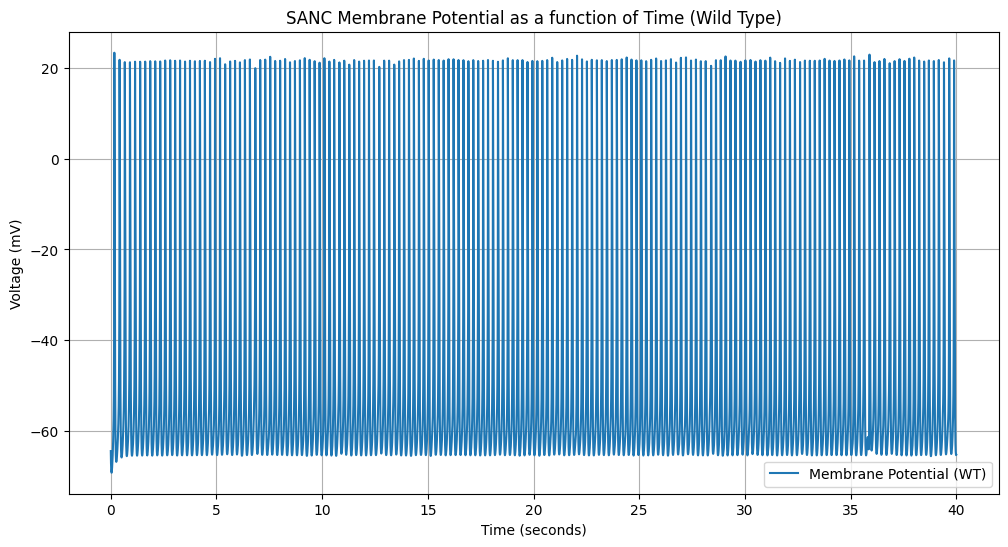

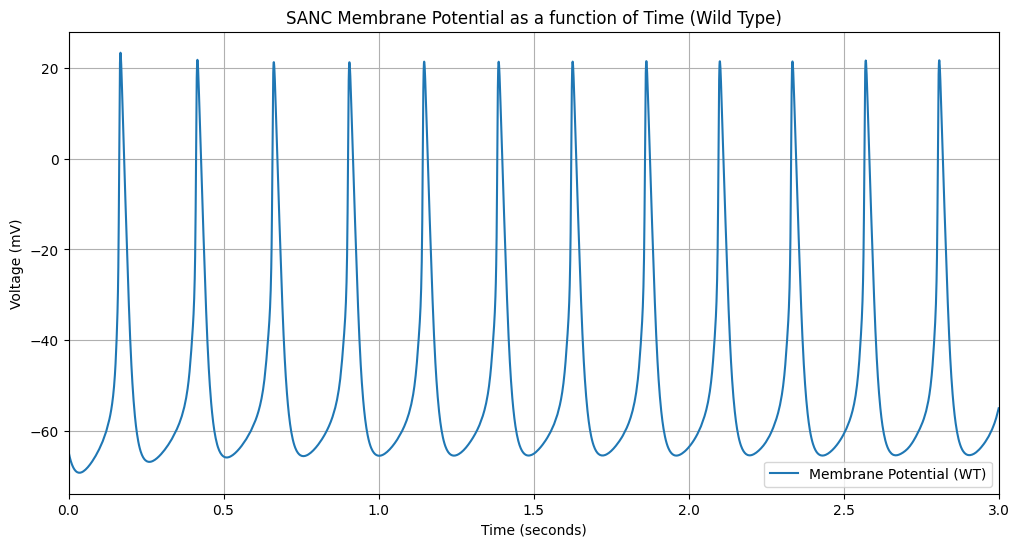

In [35]:
# ---------- Initial conditions ----------
Y0 = np.zeros(43)

Y0[0]  = -64.5216286940   # Vm
Y0[1]  = 0.6246780312     # qa
Y0[2]  = 0.4537033169     # qi
Y0[3]  = 0.0016256324     # dT
Y0[4]  = 0.4264459666     # fT
Y0[5]  = 0.4043600437     # pa
Y0[6]  = 0.9250035423     # pi
Y0[7]  = 0.0127086259     # xs
Y0[8]  = 0.9968141226     # fL12
Y0[9]  = 0.0000045583     # dL12
Y0[10] = 0.9809298233     # fL13
Y0[11] = 0.0002036671     # dL13
Y0[12] = 0.7649576191     # fCa
Y0[13] = 0.0046263658     # r
Y0[14] = 0.6107148187     # q
Y0[15] = 0.4014088304     # m15
Y0[16] = 0.2724817537     # h15
Y0[17] = 0.0249208708     # j15
Y0[18] = 0.1079085266     # m11
Y0[19] = 0.4500098710     # h11
Y0[20] = 0.0268486392     # j11
Y0[21] = 0.0279984462     # y
Y0[22] = 0.0000319121     # Cai
Y0[23] = 0.1187281829     # CajSR
Y0[24] = 1.5768287365     # CanSR
Y0[25] = 0.0000560497     # Casub
Y0[26] = 0.0063427103     # fTC
Y0[27] = 0.1296677919     # fTMC
Y0[28] = 0.7688656371     # fTMM
Y0[29] = 0.0242054739     # fCMs
Y0[30] = 0.0138533048     # fCMi
Y0[31] = 0.1203184861     # fCQ
Y0[32] = 0.7720290515     # R
Y0[33] = 7.60e-8          # OO
Y0[34] = 2.13e-8          # S
Y0[35] = 0.2162168926     # RI
Y0[36] = 0.0004           # w
Y0[37] = 19.73            # cAMP
Y0[38] = 0.23             # PLB
Y0[39] = 0.06             # A
Y0[40] = 0.02             # TT
Y0[41] = 0.06             # U
Y0[42] = 1.75e-6          # SL

# %% *************************Add your code here**************************

# --- Question 4 ---
# Define the time span for the simulation: 40 seconds * 1000 = 40,000 ms
t_start = 0
t_end = 40000
t_span = (t_start, t_end)

# Call the ODE solver (solve_ivp)
sol = solve_ivp(diff_eq, t_span, Y0, method='BDF')

# Extract the results
time_ms = sol.t          # Time points in milliseconds
voltage_mv = sol.y[0]    # Membrane potential (Vm) is the first variable in our Y vector

# Display the membrane voltage as a function of time 
plt.figure(figsize=(12, 6))
plt.plot(time_ms / 1000, voltage_mv, label='Membrane Potential (WT)') # Convert ms to seconds for the x-axis
plt.title('SANC Membrane Potential as a function of Time (Wild Type)')
plt.xlabel('Time (seconds)')
plt.ylabel('Voltage (mV)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(time_ms / 1000, voltage_mv, label='Membrane Potential (WT)') # Convert ms to seconds for the x-axis
plt.title('SANC Membrane Potential as a function of Time (Wild Type)')
plt.xlabel('Time (seconds)')
plt.xlim(0,3)
plt.ylabel('Voltage (mV)')
plt.grid(True)
plt.legend()
plt.show()

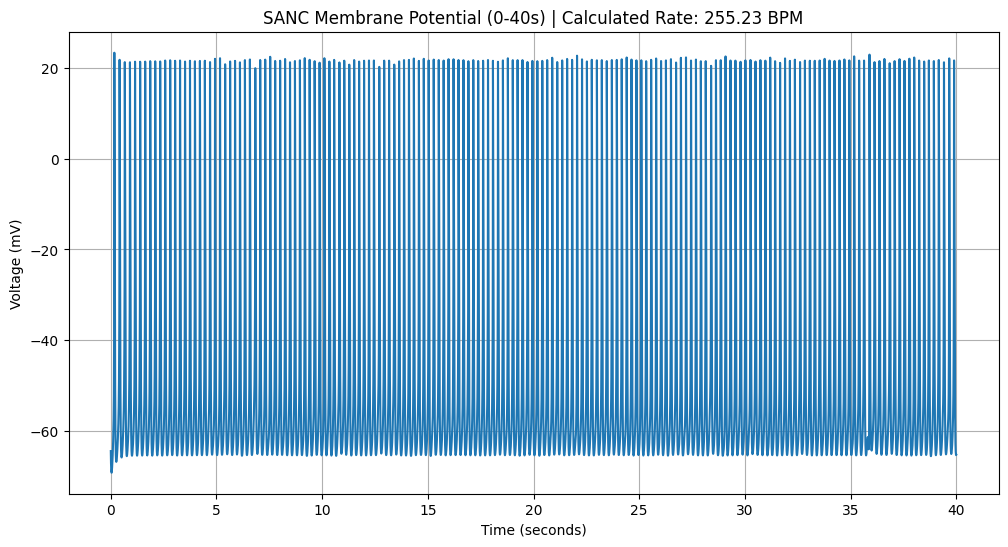

Average Cycle Length (CL): 235.09 ms
Calculated Beating Rate: 255.23 BPM


In [36]:
# --- Question 5 ---

# Analyze the entire signal from 0s to 40s
start_time = 0 # ms
end_time = 40000   # ms
indices = np.where((time_ms >= start_time) & (time_ms <= end_time))[0]

time_segment = time_ms[indices]
voltage_segment = voltage_mv[indices]

# Peak Detection Algorithm
# We identify a peak if a point is higher than its neighbors and above a 0 mV to avoid noise.
peaks_time = []
threshold = 0 

for i in range(1, len(voltage_segment) - 1):
    if (voltage_segment[i] > voltage_segment[i-1] and voltage_segment[i] > voltage_segment[i+1] and voltage_segment[i] > threshold):
        peaks_time.append(time_segment[i])

# Calculate Cycle Lengths (CL) and Average Beating Rate
# CL is the time difference between consecutive peaks in ms
cycle_lengths = np.diff(peaks_time)
avg_cl_ms = np.mean(cycle_lengths)

# Rate in Beats Per Minute (BPM): 60,000 ms per minute / average CL in ms
beating_rate = 60000 / avg_cl_ms

plt.figure(figsize=(12, 6))
plt.plot(time_segment / 1000, voltage_segment)
plt.title(f'SANC Membrane Potential (0-40s) | Calculated Rate: {beating_rate:.2f} BPM')
plt.xlabel('Time (seconds)')
plt.ylabel('Voltage (mV)')
plt.grid(True)
plt.show()

print(f"Average Cycle Length (CL): {avg_cl_ms:.2f} ms")
print(f"Calculated Beating Rate: {beating_rate:.2f} BPM")

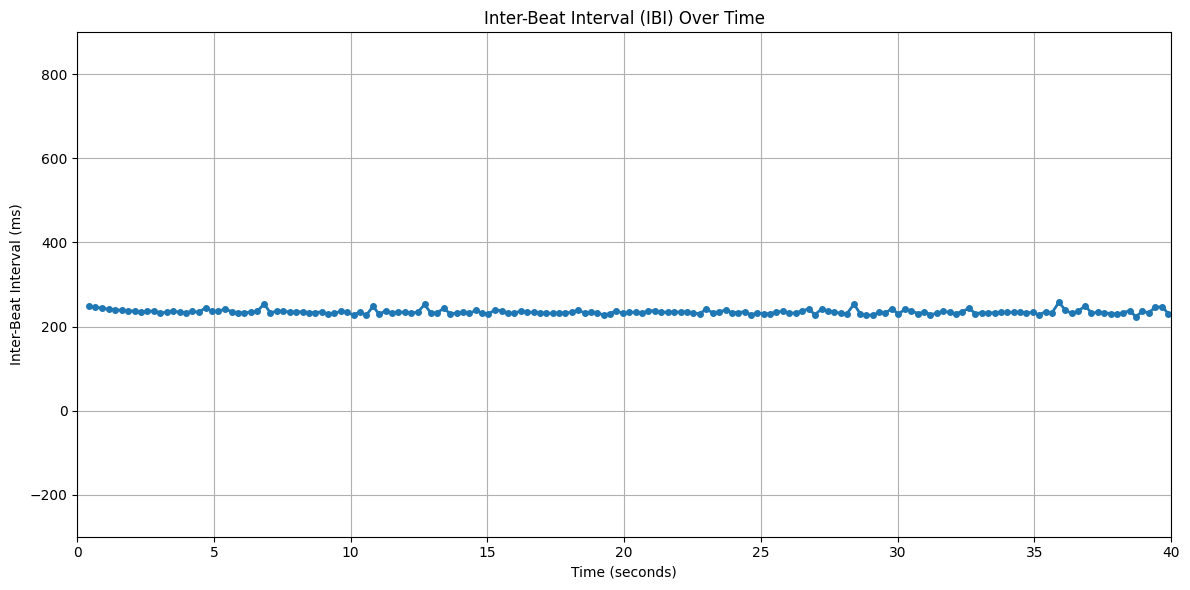

Number of beats detected: 170
Number of IBIs: 169


In [37]:
# --- Question 1.3 ---
# Calculate Inter-Beat Intervals (IBI) and plot over time
peaks_time_array = np.array(peaks_time)

IBIs = np.diff(peaks_time_array)  

IBI_times = peaks_time_array[1:]  

# Plot IBI over time
plt.figure(figsize=(12, 6))
plt.plot(IBI_times / 1000, IBIs, marker='o', linestyle='-', linewidth=2, markersize=4)
plt.xlim(0, 40)
plt.ylim(-300, 900)
plt.title('Inter-Beat Interval (IBI) Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Inter-Beat Interval (ms)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Number of beats detected: {len(peaks_time)}")
print(f"Number of IBIs: {len(IBIs)}")

In [38]:
# --- Question 1.4 ---
# Calculate Heart Rate Variability (HRV) Parameters

# 1. Mean Beat Interval
mean_IBI = np.mean(IBIs)

# 2. Standard Deviation (SDNN) 
SDNN = np.std(IBIs, ddof=1)  

# 3. Coefficient of Variation (CV) - SDNN as percentage of mean
CV = (SDNN / mean_IBI) * 100

# 4. RMSSD - Root Mean Square of Successive Differences
successive_differences = np.diff(IBIs)
RMSSD = np.sqrt(np.mean(successive_differences ** 2))

# 5. pNN5 - Percentage of successive NN intervals that differ by more than 5 ms
nn5_count = np.sum(np.abs(successive_differences) > 5)
pNN5 = (nn5_count / len(successive_differences)) * 100

# Display results
print("HEART RATE VARIABILITY (HRV) PARAMETERS")
print(f"Mean Beat Interval:  {mean_IBI:.2f} ms")
print(f"SDNN (Std Dev):      {SDNN:.2f} ms")
print(f"CV (Coefficient of Variation): {CV:.2f} %")
print(f"RMSSD:               {RMSSD:.2f} ms")
print(f"pNN5:                {pNN5:.2f} %")


HEART RATE VARIABILITY (HRV) PARAMETERS
Mean Beat Interval:  235.09 ms
SDNN (Std Dev):      5.30 ms
CV (Coefficient of Variation): 2.26 %
RMSSD:               7.44 ms
pNN5:                33.93 %


c:\Users\Meital\Bio-electrical phenomenas\Part 3\diff_eq.py:276: RuntimeWarning: invalid value encountered in scalar power
  kCaSR = con.MaxSR - (con.MaxSR - con.MinSR) / (1.0 + (con.EC_50SR / CajSR)**con.HSR)
c:\Users\Meital\Bio-electrical phenomenas\Part 3\diff_eq.py:61: RuntimeWarning: invalid value encountered in log
  ECa = (con.E_T / 2.0) * np.log(con.Cao / Casub)


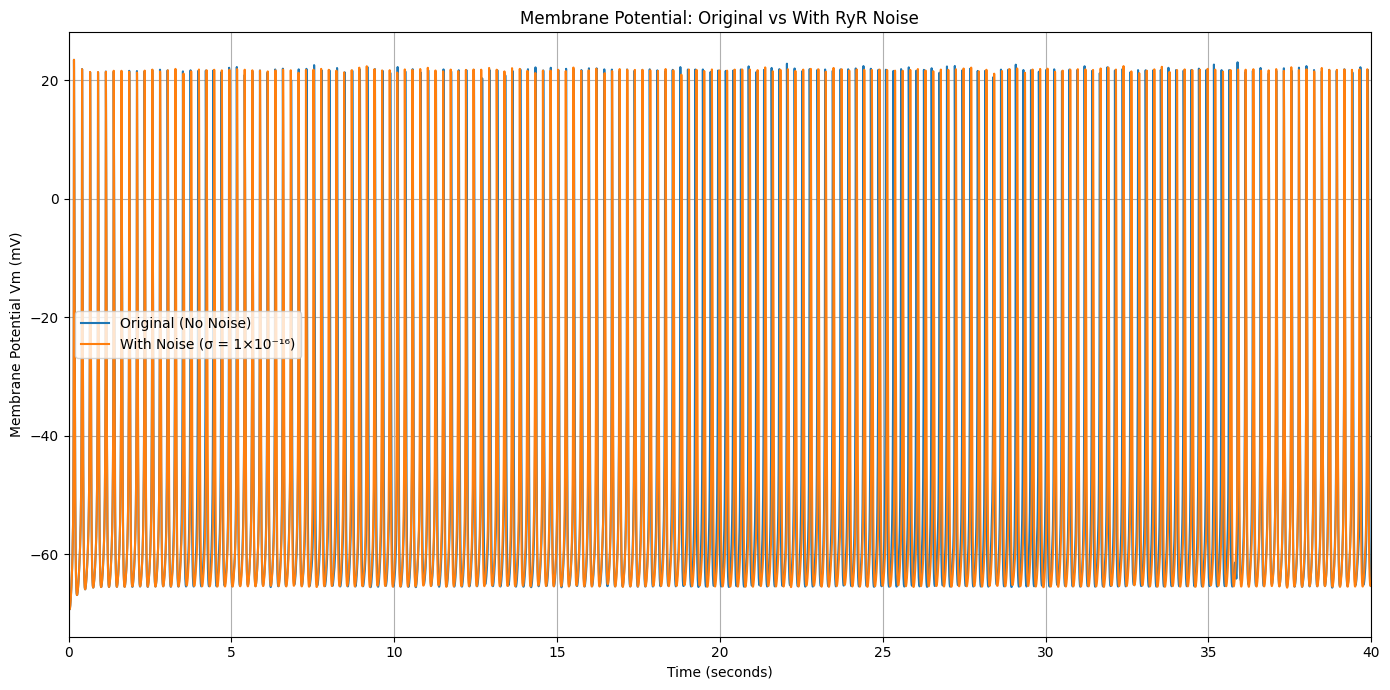

In [40]:
# --- Question 2.3 ---

# Store original results from Section 1.2 (no noise)
time_original = time_ms.copy()
voltage_original = voltage_mv.copy()

# Run simulation with noise 
np.random.seed(42)
sol_noise = solve_ivp(diff_eq, t_span, Y0, method='BDF')

time_noise = sol_noise.t
voltage_noise = sol_noise.y[0]

# Plot membrane potential comparison on the same axes
plt.figure(figsize=(14, 7))
plt.plot(time_original / 1000, voltage_original, label='Original (No Noise)', linewidth=1.5)
plt.plot(time_noise / 1000, voltage_noise, label='With Noise (σ = 1×10⁻¹⁶)', linewidth=1.5)

plt.xlabel('Time (seconds)')
plt.ylabel('Membrane Potential Vm (mV)')
plt.title('Membrane Potential: Original vs With RyR Noise')
plt.xlim(0, 40)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



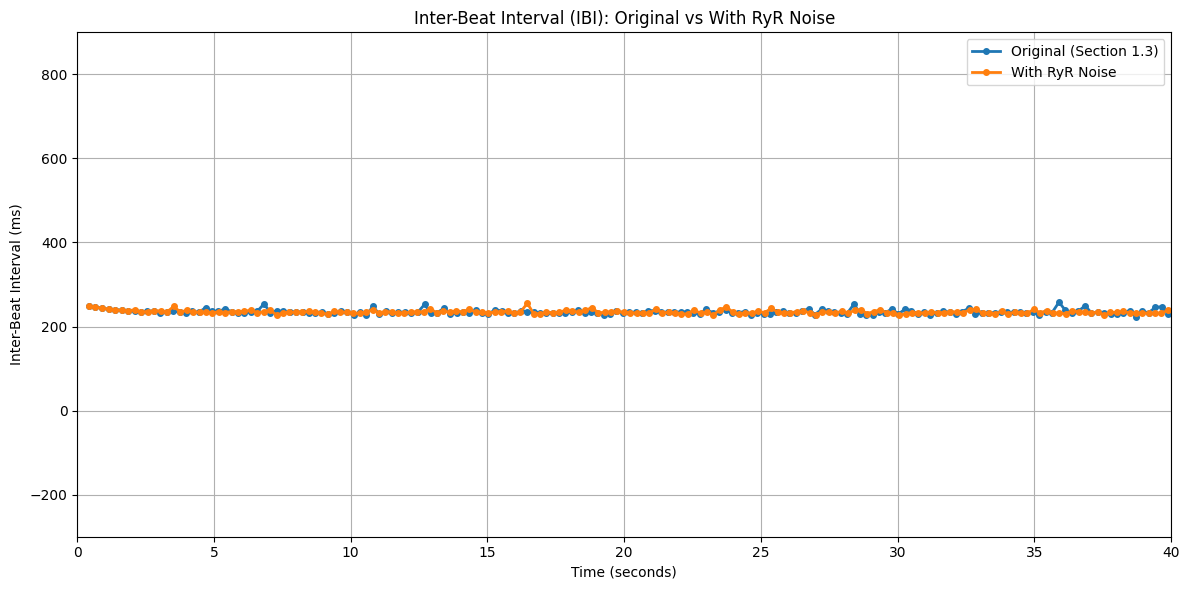

In [41]:
# --- Question 2.4 ---
# Calculate IBI after adding RyR noise

# Detect peaks for noisy simulation
peaks_time_noise = []

for i in range(1, len(voltage_noise) - 1):
    if voltage_noise[i-1] < voltage_noise[i] and voltage_noise[i] > voltage_noise[i+1] and voltage_noise[i] > 0:
        peaks_time_noise.append(time_noise[i])

peaks_time_noise_array = np.array(peaks_time_noise)

IBIs_noise = np.diff(peaks_time_noise_array)
IBI_times_noise = peaks_time_noise_array[1:]

# Plot IBI comparison on the same axes
plt.figure(figsize=(12, 6))
plt.plot(IBI_times / 1000, IBIs, marker='o', linestyle='-', linewidth=2, markersize=4,
         label='Original (Section 1.3)')
plt.plot(IBI_times_noise / 1000, IBIs_noise, marker='o', linestyle='-', linewidth=2, markersize=4,
         label='With RyR Noise')

plt.xlim(0, 40)
plt.ylim(-300, 900)
plt.title('Inter-Beat Interval (IBI): Original vs With RyR Noise')
plt.xlabel('Time (seconds)')
plt.ylabel('Inter-Beat Interval (ms)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
# --- Question 2.5 ---
# HRV with RyR noise 

# 1. Mean Beat Interval
mean_IBI_noise = np.mean(IBIs_noise)

# 2. Standard Deviation (SDNN)
SDNN_noise = np.std(IBIs_noise, ddof=1)

# 3. Coefficient of Variation (CV)
CV_noise = (SDNN_noise / mean_IBI_noise) * 100

# 4. RMSSD
successive_differences_noise = np.diff(IBIs_noise)
RMSSD_noise = np.sqrt(np.mean(successive_differences_noise ** 2))

# 5. pNN5
nn5_count_noise = np.sum(np.abs(successive_differences_noise) > 5)
pNN5_noise = (nn5_count_noise / len(successive_differences_noise)) * 100


# ----- Comparison table -----
import pandas as pd

results_25 = pd.DataFrame({
    "Original (Section 1.4)": [mean_IBI, SDNN, CV, RMSSD, pNN5],
    "With RyR Noise (Section 2.5)": [mean_IBI_noise, SDNN_noise, CV_noise, RMSSD_noise, pNN5_noise]
}, index=["Mean IBI (ms)", "SDNN (ms)", "CV (%)", "RMSSD (ms)", "pNN5 (%)"])

results_25


,Original (Section 1.4),With RyR Noise (Section 2.5)
Mean IBI (ms),235.085408,234.975896
SDNN (ms),5.303746,4.080597
CV (%),2.256093,1.736602
RMSSD (ms),7.435214,5.271041
pNN5 (%),33.928571,24.404762


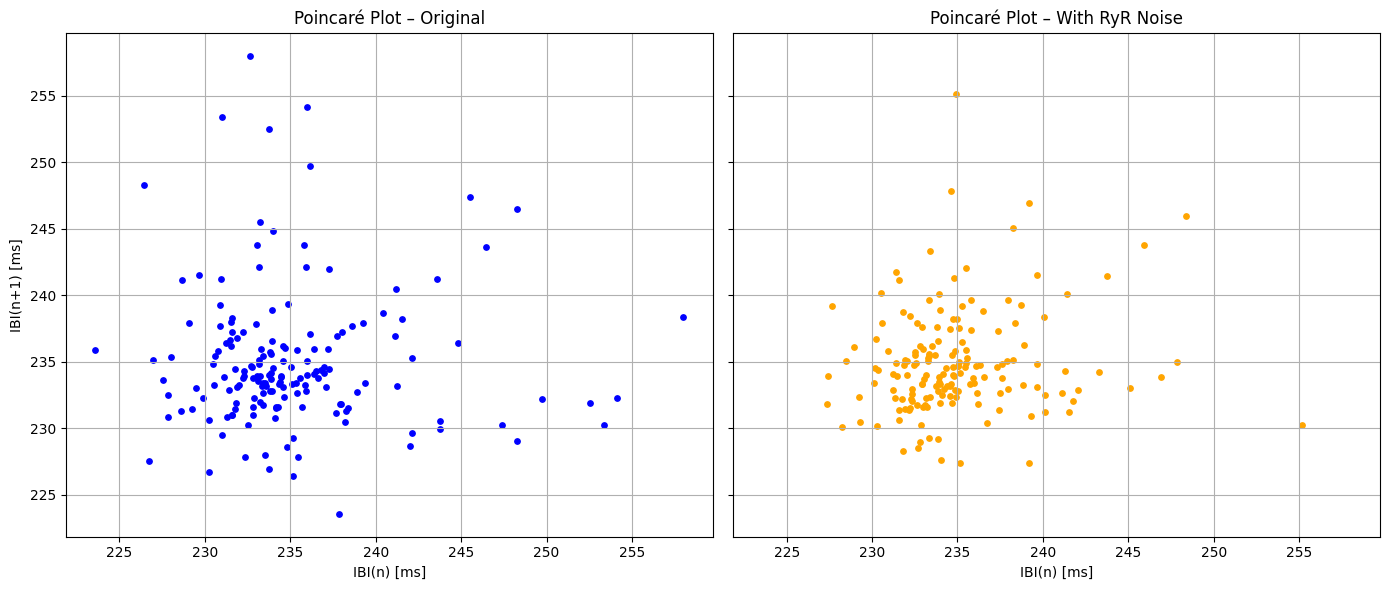

In [43]:
# --- Question 2.6 ---
# Poincaré plots: IBI(n+1) vs IBI(n) using subplots

# Data for Poincaré plots
x_orig = IBIs[:-1]
y_orig = IBIs[1:]

x_noise = IBIs_noise[:-1]
y_noise = IBIs_noise[1:]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ----- Original (before noise) -----
axes[0].scatter(x_orig, y_orig, s=15, color='blue')
axes[0].set_title('Poincaré Plot – Original')
axes[0].set_xlabel('IBI(n) [ms]')
axes[0].set_ylabel('IBI(n+1) [ms]')
axes[0].grid(True)

# ----- With RyR noise -----
axes[1].scatter(x_noise, y_noise, s=15, color='orange')
axes[1].set_title('Poincaré Plot – With RyR Noise')
axes[1].set_xlabel('IBI(n) [ms]')
axes[1].grid(True)

plt.tight_layout()
plt.show()



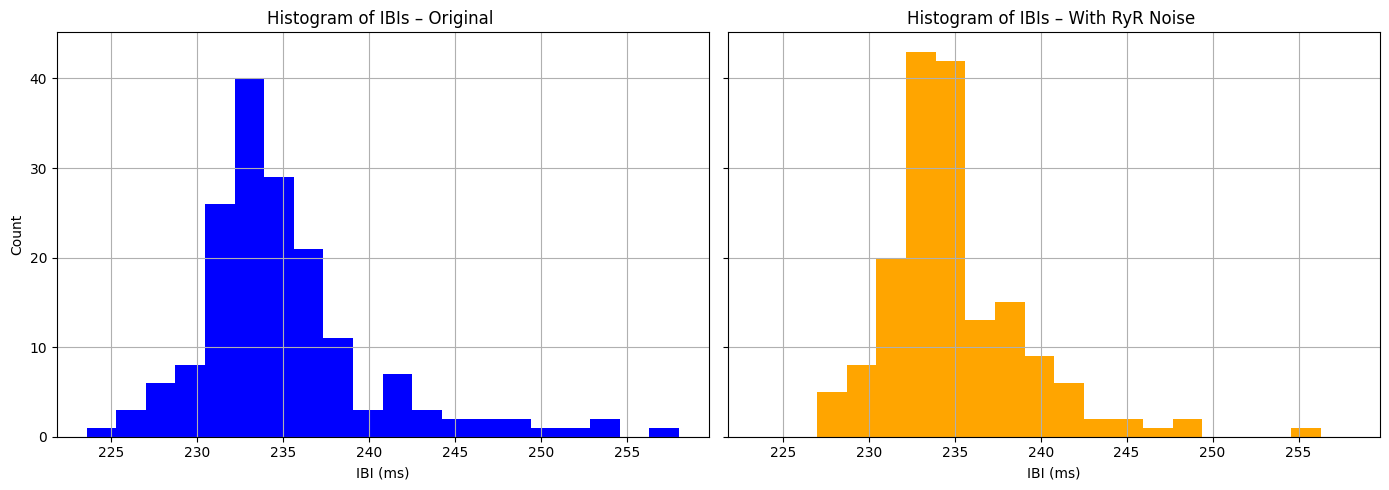

In [44]:
# --- Question 2.7 ---
# Histograms of beat intervals (IBIs): before noise vs with RyR noise

bins = 20
min_edge = min(np.min(IBIs), np.min(IBIs_noise))
max_edge = max(np.max(IBIs), np.max(IBIs_noise))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

axes[0].hist(IBIs, bins=bins, range=(min_edge, max_edge), color='blue')
axes[0].set_title('Histogram of IBIs – Original ')
axes[0].set_xlabel('IBI (ms)')
axes[0].set_ylabel('Count')
axes[0].grid(True)

axes[1].hist(IBIs_noise, bins=bins, range=(min_edge, max_edge), color='orange')
axes[1].set_title('Histogram of IBIs – With RyR Noise ')
axes[1].set_xlabel('IBI (ms)')
axes[1].grid(True)

plt.tight_layout()
plt.show()
